# Домашняя работа №1
## Линейная регрессия: обучение, масштаб и надёжность эксперимента

**Оценка:** 10 баллов.  

В этой работе мы продолжим разбирать механику обучения линейной регрессии. Сначала реализуем обучение по батчам, затем посмотрим, почему масштаб признаков важен для градиентных методов, разберём несколько критериев остановки и в конце исследуем, насколько случайным может быть значение метрики на конечной тестовой выборке.

Большая часть инфраструктуры уже подготовлена. Основная цель — не написать как можно больше кода, а провести аккуратные эксперименты и объяснить, что именно в них произошло.

| Раздел | Баллы |
|---|---:|
| A. Обучение по батчам и эпохи | 3 |
| B. Масштаб признаков | 2 |
| C. Размер батча и остановка обучения | 2 |
| D. Случайность оценки качества | 2 |
| E. Итоговая диагностика | 1 |
| **Итого** | **10** |

Внутри работы есть **9 заданий**. Задание 1 оценивается в 2 балла, остальные — в 1 балл каждое.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

np.set_printoptions(precision=4, suppress=True)


# 0. Синтетическая задача и вспомогательные функции

Во всей работе используется одна и та же синтетическая задача регрессии. Это удобно: мы точно знаем, как устроен процесс генерации данных, и можем получать сколько угодно независимых выборок из одного и того же распределения.

Признаки генерируются так:

$$
x_1 \sim \mathcal N(0,1),
$$

$$
x_2 \sim \mathcal N(0,20^2).
$$

Целевая переменная задаётся линейной зависимостью с шумом:

$$
y = 5 + 2x_1 + 0.04x_2 + \varepsilon,
\qquad
\varepsilon \sim \mathcal N(0,4^2).
$$

Оба признака полезны для предсказания, но их численные масштабы сильно различаются: типичное значение $x_1$ имеет порядок единицы, а $x_2$ — порядок десятков. Позже это различие станет важным.

Ниже собраны вспомогательные функции. Их **не нужно переписывать**: прочитайте докстринги и используйте функции дальше по работе.

In [2]:
# DGP = Data Generating Process — параметры процесса генерации данных.
DGP = {
    "intercept": 5.0,
    "beta1": 2.0,
    "beta2": 0.04,
    "x2_scale": 20.0,
    "noise_scale": 4.0,
}


def sample_regression(n, random_state):
    """Сгенерировать независимую выборку из заданного процесса генерации данных.

    Параметры
    ---------
    n : int
        Размер выборки.
    random_state : int
        Зерно генератора случайных чисел. Одинаковое значение даёт
        одинаковую выборку и делает эксперимент воспроизводимым.

    Возвращает
    ----------
    X : pandas.DataFrame
        Таблица с двумя признаками: x1 и x2.
    y : numpy.ndarray
        Целевая переменная.
    """
    rng = np.random.default_rng(random_state)
    x1 = rng.normal(0.0, 1.0, size=n)
    x2 = rng.normal(0.0, DGP["x2_scale"], size=n)
    eps = rng.normal(0.0, DGP["noise_scale"], size=n)

    y = (
        DGP["intercept"]
        + DGP["beta1"] * x1
        + DGP["beta2"] * x2
        + eps
    )

    X = pd.DataFrame({"x1": x1, "x2": x2})
    return X, y


def add_intercept(X):
    """Добавить слева столбец единиц для свободного члена линейной модели."""
    X_arr = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X_arr)), X_arr])


def mse_loss(theta, X_aug, y):
    """Посчитать среднюю квадратичную ошибку для заданного вектора параметров."""
    residuals = np.asarray(y, dtype=float) - np.asarray(X_aug, dtype=float) @ theta
    return float(np.mean(residuals ** 2))


def mse_gradient(theta, X_aug, y):
    """Посчитать градиент MSE по параметрам линейной модели."""
    X_aug = np.asarray(X_aug, dtype=float)
    y = np.asarray(y, dtype=float)
    return -(2.0 / len(y)) * X_aug.T @ (y - X_aug @ theta)


def rmse(y_true, y_pred):
    """Посчитать корень из средней квадратичной ошибки (RMSE)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def fit_lstsq(X, y):
    """Решить задачу МНК численным решателем ``np.linalg.lstsq``.

    Функция сама добавляет столбец единиц для свободного члена и
    возвращает вектор ``theta = [intercept, coef_1, coef_2, ...]``.
    """
    theta, *_ = np.linalg.lstsq(add_intercept(X), y, rcond=None)
    return theta


def predict_theta(theta, X):
    """Получить предсказания линейной модели для фиксированного вектора theta."""
    return add_intercept(X) @ theta


N_TRAIN = 640
TRAIN_SEED = 7

X_train, y_train = sample_regression(N_TRAIN, TRAIN_SEED)

print("Размер обучающей выборки:", X_train.shape)
display(X_train.head())

Размер обучающей выборки: (640, 2)


,x1,x2
0,0.001230,-18.302353
1,0.298746,6.737050
2,-0.274138,-13.173873
3,-0.890592,-30.448556
4,-0.454671,20.769599


## Эталонное решение задачи МНК

На второй неделе мы решали задачу метода наименьших квадратов. Ниже $X$ обозначает матрицу признаков **вместе со столбцом единиц для свободного члена**. Задача имеет вид

$$
\hat\theta
=
\arg\min_{\theta}
\frac{1}{n}\lVert y-X\theta\rVert_2^2.
$$

Если столбцы $X$ линейно независимы, минимум единственный. Тогда знакомая формула

$$
\hat\theta=(X^TX)^{-1}X^Ty
$$

задаёт тот же самый оптимальный вектор параметров, который находит `np.linalg.lstsq`, с точностью до обычных ошибок вычислений с числами с плавающей точкой.

Если между столбцами $X$ есть **точная** линейная зависимость, ранг матрицы меньше числа параметров. Тогда $X^TX$ необратима, формула через явную обратную матрицу не определена, а минимум задачи МНК уже не единственен. В такой ситуации существует бесконечно много наборов коэффициентов, которые дают одинаковые предсказания и одинаковое минимальное значение MSE.

`np.linalg.lstsq` всё равно решает саму задачу наименьших квадратов и возвращает **один** из минимизаторов; при неединственности — решение с минимальной евклидовой нормой. Это численный решатель линейной алгебры: он использует матричные разложения и не вычисляет $(X^TX)^{-1}$ напрямую.

Поэтому полезно различать три вещи:

- формула нормальных уравнений — аналитическая запись решения при полном ранге;
- `lstsq` — численный прямой решатель задачи МНК;
- градиентный спуск — численный **итерационный** способ постепенно приблизиться к минимуму.

Все вычисления на компьютере конечной точности, поэтому и результат `lstsq` численно приближённый. Но в этой работе мы будем считать его практически точным **эталоном по значению MSE** для нашей небольшой задачи: если градиентный алгоритм ещё заметно выше MSE, достигнутой `lstsq`, значит он пока не решил ту же задачу оптимизации достаточно хорошо.


In [3]:
theta_lstsq = fit_lstsq(X_train, y_train)
reference_mse = mse_loss(theta_lstsq, add_intercept(X_train), y_train)
reference_rmse = np.sqrt(reference_mse)

print("Параметры lstsq:", theta_lstsq)
print(f"MSE на обучающей выборке:  {reference_mse:.4f}")
print(f"RMSE на обучающей выборке: {reference_rmse:.4f}")

Параметры lstsq: [5.03   1.9868 0.0388]
MSE на обучающей выборке:  17.2568
RMSE на обучающей выборке: 4.1541


# A. Обучение по батчам и эпохи — 3 балла

На семинаре мы реализовывали обычный градиентный спуск: на каждом шаге считали градиент MSE по **всей** обучающей выборке и после этого обновляли параметры.

Теперь перейдём к обучению по небольшим частям данных.

## От случайного батча к эпохе

На лекции мы обсуждали простую стохастическую схему:

1. случайно выбрать объект или небольшой батч;
2. оценить по нему градиент;
3. обновить параметры;
4. снова независимо выбрать следующий батч.

Если выбирать батчи независимо **с возвращением**, один объект может встретиться несколько раз, а другой за то же число шагов — ни разу. Такая схема вполне корректна и удобна для теоретического описания SGD.

При обучении на конечном наборе данных очень часто используют другую организацию — и в классическом машинном обучении, и в глубоком обучении:

1. в начале прохода случайно перемешивают индексы всех объектов;
2. получившийся порядок разбивают на непересекающиеся батчи;
3. последовательно проходят батчи и после каждого обновляют параметры;
4. после последнего батча снова перемешивают данные и начинают новый проход.

Такую схему называют **перемешиванием без повторений внутри прохода** (`random reshuffling`). Например, `SGDRegressor` в `scikit-learn` при `shuffle=True` перемешивает обучающие объекты между проходами по данным.

Почему эта схема удобна на практике:

- за один проход каждый объект гарантированно используется ровно один раз;
- случайность порядка и состава батчей сохраняется;
- появляется естественная единица прогресса обучения;
- удобно сравнивать, сколько раз алгоритм уже просмотрел весь набор данных.

**Один полный проход по всей обучающей выборке будем называть эпохой (`epoch`).**

Например, если есть 12 объектов и `batch_size=4`, одна эпоха содержит три обновления параметров. После неё данные перемешиваются заново, и начинается следующая эпоха.

Если размер выборки не делится на размер батча нацело, последний батч просто получается меньше. Например, при 10 объектах и `batch_size=4` размеры батчей будут $4$, $4$ и $2$: ни один объект не теряется.


In [4]:
# Небольшая иллюстрация того, как устроена эпоха.
rng_demo = np.random.default_rng(17)
n_demo = 12
batch_size_demo = 4

for epoch in range(1, 3):
    order = rng_demo.permutation(n_demo)
    batches = [
        order[start:start + batch_size_demo].tolist()
        for start in range(0, n_demo, batch_size_demo)
    ]
    print(f"Эпоха {epoch}: {batches}")

Эпоха 1: [[8, 4, 6, 11], [1, 0, 10, 7], [9, 2, 5, 3]]
Эпоха 2: [[3, 6, 0, 2], [4, 5, 9, 10], [8, 7, 11, 1]]


Обратите внимание: внутри одной эпохи все номера от 0 до 11 встретились ровно один раз. При этом во второй эпохе порядок уже другой.

Если в нашей основной выборке $n=640$, то:

| Размер батча | Обновлений параметров за эпоху |
|---:|---:|
| 640 | 1 |
| 32 | 20 |
| 1 | 640 |

Поэтому одинаковое число эпох означает, что алгоритмы примерно одинаковое число раз **увидели обучающие объекты**, но это не означает одинаковое число обновлений параметров или одинаковое время работы.

## Задание 1. Реализуйте `LinearRegressionSGD` — 2 балла

Ниже дан каркас учебного класса линейной регрессии. Реализуйте `fit` **строго по описанному контракту**. Мы намеренно фиксируем детали алгоритма: дальше будем сравнивать запуски и хотим быть уверены, что различается только тот фактор, который мы меняем в эксперименте.

Логика одного вызова `fit` должна буквально повторять схему выше:

1. добавить к признакам столбец единиц для свободного члена;
2. начать с нулевого вектора параметров;
3. создать генератор случайных чисел

```python
rng = np.random.default_rng(self.random_state)
```

   `rng` — объект NumPy, который генерирует воспроизводимые псевдослучайные перестановки. Если `random_state` одинаковый, последовательность перестановок тоже будет одинаковой;
4. для каждой эпохи получить `order = rng.permutation(n_objects)`;
5. идти по этой перестановке кусками длины `batch_size`; последний кусок может быть короче;
6. на каждом батче вычислять градиент функцией `mse_gradient` и делать обновление

$$
\theta \leftarrow \theta - \eta\nabla R_B(\theta);
$$

7. после того как закончились **все** батчи эпохи, посчитать диагностические величины уже по всей обучающей выборке;
8. перейти к следующей эпохе.

В этом задании **нет досрочной остановки**: класс всегда выполняет ровно `max_epochs` полных эпох. К критериям остановки вернёмся отдельно в разделе C.

После обучения сохраните:

- `theta_` — полный вектор параметров;
- `intercept_` — свободный член;
- `coef_` — коэффициенты при признаках;
- `history_` — историю обучения.

В `history_` после каждой эпохи должны появляться:

- `train_mse` — MSE на всей обучающей выборке;
- `full_grad_norm` — норма градиента MSE по всей обучающей выборке;
- `epoch_step_norm` — длина изменения вектора параметров за эпоху;
- `n_updates` — накопленное число обновлений параметров.

<details>
<summary><strong>Подсказка по структуре цикла</strong></summary>

<pre><code>for epoch in range(self.max_epochs):
    order = rng.permutation(n_objects)

    for start in range(0, n_objects, self.batch_size):
        batch_idx = order[start:start + self.batch_size]
        # градиент на батче
        # обновление theta

    # диагностика после полной эпохи
</code></pre>
</details>

Метод `predict` уже реализован.


In [5]:
class LinearRegressionSGD:

    def __init__(self, learning_rate, batch_size, max_epochs, random_state=42):
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.random_state = random_state

    def fit(self, X, y):
        X_aug = add_intercept(X)
        y_arr = np.asarray(y, dtype=float)
        n_objects = len(y_arr)
        theta = np.zeros(X_aug.shape[1], dtype=float)
        rng = np.random.default_rng(self.random_state)

        train_mse_history = []
        full_grad_norm_history = []
        epoch_step_norm_history = []
        n_updates_history = []
        total_updates = 0

        for epoch in range(self.max_epochs):
            order = rng.permutation(n_objects)
            theta_start = theta.copy()

            for start in range(0, n_objects, self.batch_size):
                batch_idx = order[start:start + self.batch_size]
                grad = mse_gradient(theta, X_aug[batch_idx], y_arr[batch_idx])
                theta = theta - self.learning_rate * grad
                total_updates += 1

            train_mse = mse_loss(theta, X_aug, y_arr)
            full_grad = mse_gradient(theta, X_aug, y_arr)
            full_grad_norm = float(np.linalg.norm(full_grad))
            epoch_step_norm = float(np.linalg.norm(theta - theta_start))

            train_mse_history.append(train_mse)
            full_grad_norm_history.append(full_grad_norm)
            epoch_step_norm_history.append(epoch_step_norm)
            n_updates_history.append(total_updates)

        self.theta_ = theta
        self.intercept_ = float(theta[0])
        self.coef_ = theta[1:].copy()
        self.history_ = {
            "train_mse": np.asarray(train_mse_history, dtype=float),
            "full_grad_norm": np.asarray(full_grad_norm_history, dtype=float),
            "epoch_step_norm": np.asarray(epoch_step_norm_history, dtype=float),
            "n_updates": np.asarray(n_updates_history, dtype=int),
        }
        return self

    def predict(self, X):
        return add_intercept(X) @ self.theta_

## Задание 2. Проверьте реализацию — 1 балл

Сначала проверим класс на небольшой хорошо обусловленной задаче, где оба признака имеют похожий масштаб. Здесь специально нет проблемы разных масштабов: сейчас мы хотим проверить именно **логику обучения**.

Ячейка ниже делает две вещи.

1. Автотесты проверяют технический контракт класса: размеры результатов, длину истории, число обновлений и воспроизводимость при одинаковом `random_state`.
2. Затем ваша full-batch версия (`batch_size=len(X_small)`) сравнивается с `lstsq` по итоговой MSE.

Если всё реализовано правильно, все `assert` должны пройти, а MSE двух методов должны практически совпасть.

После выполнения ячейки ответьте на вопрос:

> **Что именно проверили автотесты? Что показывает близость MSE нашей реализации к `lstsq`? Почему после этого класс можно использовать в следующих экспериментах?**


In [6]:
def _make_small_problem(n=120, random_state=123):
    """Маленькая линейная задача для проверки реализации."""
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n, 2))
    y = 1.0 + 2.0 * X[:, 0] - 3.0 * X[:, 1] + rng.normal(0, 0.2, size=n)
    return X, y


X_small, y_small = _make_small_problem()

check_model = LinearRegressionSGD(
    learning_rate=0.05,
    batch_size=len(X_small),
    max_epochs=200,
    random_state=11,
).fit(X_small, y_small)

# Технические проверки контракта класса.
assert check_model.predict(X_small).shape == (len(X_small),)
assert len(check_model.coef_) == 2
assert len(check_model.history_["train_mse"]) == 200
assert check_model.history_["n_updates"][-1] == 200

# Проверка воспроизводимости при одинаковом random_state.
check_model_2 = LinearRegressionSGD(
    learning_rate=0.05,
    batch_size=len(X_small),
    max_epochs=200,
    random_state=11,
).fit(X_small, y_small)
assert np.allclose(check_model.theta_, check_model_2.theta_)

# Сравнение с эталонным решением задачи МНК.
small_theta_ref = fit_lstsq(X_small, y_small)
small_mse_ref = mse_loss(small_theta_ref, add_intercept(X_small), y_small)
small_mse_gd = mse_loss(check_model.theta_, add_intercept(X_small), y_small)

print(f"MSE градиентного спуска: {small_mse_gd:.6f}")
print(f"MSE lstsq:               {small_mse_ref:.6f}")
print(f"Абсолютная разница:       {abs(small_mse_gd - small_mse_ref):.2e}")

assert abs(small_mse_gd - small_mse_ref) < 1e-5
print("Все автопроверки пройдены.")

MSE градиентного спуска: 0.039463
MSE lstsq:               0.039463
Абсолютная разница:       5.33e-15
Все автопроверки пройдены.


**Ваш ответ:**

Автотесты подтвердили корректность технического контракта класса и сходимость численного метода. Проверено соответствие размерностей выходного вектора предсказаний, компонент вектора коэффициентов, длины списков истории метрик и суммарного числа градиентных обновлений. Фиксация начального зерна генератора показала детерминированность процедуры перемешивания объектов и повторяемость траектории обучения. Близость значения MSE к результату аналитического решения метода наименьших квадратов свидетельствует о том, что реализованный алгоритм градиентного спуска при адекватном шаге успешно достигает глобального минимума квадратичной функции потерь. Данное совпадение подтверждает отсутствие алгоритмических ошибок в расчете частных производных и коррекции весов, что делает класс надежным инструментом для последующих исследований влияния масштаба признаков, размера батча и условий останова.

### Связь с `SGDRegressor` из `scikit-learn`

Мы написали прозрачную учебную реализацию. В `scikit-learn` есть промышленный класс [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html), который реализует ту же общую идею стохастических обновлений, но поддерживает гораздо больше настроек.

Полезно сопоставить несколько параметров:

- `max_iter` — максимальное число проходов по обучающим данным, то есть эпох;
- `shuffle=True` — перемешивать обучающие объекты между эпохами;
- `eta0` — начальный шаг обучения;
- `learning_rate` — **расписание шага обучения**, то есть правило, по которому шаг $\eta_t$ может меняться от обновления к обновлению. Например, шаг можно держать постоянным или постепенно уменьшать;
- `penalty` — регуляризация, которой в нашем учебном классе пока нет;
- `tol` — один из механизмов досрочной остановки.

Чтобы сравнение было прозрачнее, ниже мы отключим регуляризацию и досрочную остановку и выберем постоянный шаг. Затем на той же маленькой задаче сравним три решения: `lstsq`, наш класс в стохастическом режиме (`batch_size=1`) и `SGDRegressor`.

Не ждите совпадения коэффициентов до последнего знака: внутренние детали обновлений в библиотечном классе не обязаны буквально повторять наш код. Нас интересует, приходят ли все три метода к очень близкому значению MSE.


In [7]:
custom_sgd_demo = LinearRegressionSGD(
    learning_rate=0.001,
    batch_size=1,
    max_epochs=200,
    random_state=11,
).fit(X_small, y_small)

sklearn_sgd_demo = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.001,
    max_iter=200,
    tol=None,
    shuffle=True,
    random_state=11,
).fit(X_small, y_small)

comparison_sgd = pd.DataFrame({
    "метод": ["lstsq", "наш SGD", "sklearn SGDRegressor"],
    "MSE": [
        small_mse_ref,
        mse_loss(custom_sgd_demo.theta_, add_intercept(X_small), y_small),
        np.mean((y_small - sklearn_sgd_demo.predict(X_small)) ** 2),
    ],
})

display(comparison_sgd)

,метод,MSE
0,lstsq,0.039463
1,наш SGD,0.039463
2,sklearn SGDRegressor,0.039463


### После раздела A

Проверьте, что теперь вы можете своими словами объяснить различие между **батчем**, **одним обновлением параметров** и **эпохой**, а также описать, как устроено перемешивание данных между эпохами. Эти понятия понадобятся в разделе C, где мы начнём сравнивать разные размеры батча.

# B. Масштаб признаков — 2 балла

Теперь мы доверяем нашей реализации обучения и можем исследовать следующий вопрос: **почему один и тот же алгоритм обучения ведёт себя по-разному при разных масштабах признаков?**

## Почему масштаб важен для градиентного обучения

Для линейной регрессии компонента градиента по коэффициенту $\theta_j$ имеет вид

$$
\frac{\partial R}{\partial \theta_j}
=
-\frac{2}{n}
\sum_{i=1}^{n}
x_{ij}(y_i-\hat y_i).
$$

В формуле прямо присутствуют значения признака $x_{ij}$. Если один признак имеет порядок единицы, а другой — десятков или сотен, соответствующие компоненты градиента тоже могут сильно отличаться по масштабу.

В наших экспериментах шаг обучения $\eta$ **постоянный и один и тот же для всех компонент параметров**:

$$
\theta \leftarrow \theta-\eta\nabla R(\theta).
$$

Поэтому один $\eta$ должен одновременно быть разумным для всех направлений. При очень разных масштабах признаков это может сделать обучение медленным или неустойчивым.

Это не универсальное ограничение всех градиентных алгоритмов: существуют методы, которые дополнительно меняют масштаб отдельных направлений или адаптируют эффективный шаг. Здесь мы специально рассматриваем простой вариант с одним постоянным $\eta$, потому что на нём влияние масштаба видно особенно хорошо.

Стандартизация не меняет информацию в признаках и не делает линейную модель «сильнее» сама по себе. Она меняет координаты, в которых алгоритм подбирает параметры, и тем самым может заметно облегчить градиентную оптимизацию.

## Стандартизация и `StandardScaler`

Один из распространённых способов привести численные признаки к сопоставимому масштабу — **стандартизация**:

$$
z_j=\frac{x_j-\mu_j}{\sigma_j},
$$

где

- $x_j$ — исходное значение признака;
- $\mu_j$ — среднее этого признака **на обучающей выборке**;
- $\sigma_j$ — его стандартное отклонение **на обучающей выборке**;
- $z_j$ — преобразованное значение.

Для непостоянного признака после такого преобразования обучающие значения имеют среднее, численно очень близкое к $0$, и дисперсию $1$ (стандартное отклонение $1$) с точностью до ошибок вычислений. Для новых данных этого требовать нельзя: `transform` использует статистики, найденные на train, а новая выборка может иметь немного другое среднее и разброс.

В `scikit-learn` это делает класс `StandardScaler`:

1. `fit(X_train)` вычисляет и сохраняет $\mu_j$ и $\sigma_j$;
2. `transform(X_train)` или `transform(X_new)` применяет **те же** сохранённые числа;
3. `fit_transform(X_train)` — сокращённая запись двух первых действий для train.

> **Ремарка для работы с реальными данными.** После разделения данных `StandardScaler` обучают только на `X_train`, а к `X_test` применяют уже найденное преобразование. Если сначала вычислить средние и стандартные отклонения по всему датасету, информация из тестовой части попадёт в preprocessing — это будет утечка данных.

Сначала посмотрим на маленький искусственный пример.


In [8]:
X_scale_demo = pd.DataFrame({
    "малый_масштаб": [1.0, 2.0, 3.0, 4.0, 5.0],
    "большой_масштаб": [100.0, 200.0, 300.0, 400.0, 500.0],
})

scaler_demo = StandardScaler()
X_scale_demo_std = scaler_demo.fit_transform(X_scale_demo)
X_scale_demo_std = pd.DataFrame(
    X_scale_demo_std,
    columns=X_scale_demo.columns,
)

before_after = pd.DataFrame({
    "среднее до": X_scale_demo.mean(),
    "std до": X_scale_demo.std(ddof=0),
    "среднее после": X_scale_demo_std.mean(),
    "std после": X_scale_demo_std.std(ddof=0),
})

print("Исходные данные:")
display(X_scale_demo)
print("Первые две строки после стандартизации:")
display(X_scale_demo_std.head(2))
print("Средние и стандартные отклонения:")
display(before_after)


Исходные данные:


,малый_масштаб,большой_масштаб
0,1.0,100.0
1,2.0,200.0
2,3.0,300.0
3,4.0,400.0
4,5.0,500.0


Первые две строки после стандартизации:


,малый_масштаб,большой_масштаб
0,-1.414214,-1.414214
1,-0.707107,-0.707107


Средние и стандартные отклонения:


,среднее до,std до,среднее после,std после
малый_масштаб,3.0,1.414214,0.0,1.0
большой_масштаб,300.0,141.421356,0.0,1.0


Теперь применим тот же объектный интерфейс к нашей основной обучающей выборке. **Дальше во всех разделах используйте именно `X_train_scaled`, созданный здесь; новый `StandardScaler` для этой выборки создавать не нужно.**

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

scale_summary = pd.DataFrame({
    "std до стандартизации": np.asarray(X_train).std(axis=0),
    "std после стандартизации": np.asarray(X_train_scaled).std(axis=0),
}, index=["x1", "x2"])

display(scale_summary)

,std до стандартизации,std после стандартизации
x1,0.928495,1.0
x2,19.552226,1.0


## Задание 3. Что изменилось после стандартизации? — 1 балл

Сначала **уберём градиентный спуск из эксперимента** и воспользуемся `lstsq`. Так мы проверим, изменилось ли само лучшее доступное линейной модели решение, не смешивая этот вопрос с особенностями оптимизатора.

Нужно:

1. решить МНК на исходных признаках `X_train`;
2. решить МНК на `X_train_scaled`;
3. получить предсказания обеих моделей на тех же обучающих объектах;
4. сравнить коэффициенты, предсказания и минимальную MSE.

После выполнения кода ответьте:

> **Что заметно изменилось после стандартизации, а что практически не изменилось? Почему коэффициенты двух записей модели нельзя сравнивать напрямую как числа в одной и той же системе координат?**


In [10]:
theta_raw = fit_lstsq(X_train, y_train)
theta_scaled = fit_lstsq(X_train_scaled, y_train)

pred_raw = predict_theta(theta_raw, X_train)
pred_scaled = predict_theta(theta_scaled, X_train_scaled)

comparison = pd.DataFrame({
    "исходные признаки": theta_raw,
    "стандартизованные признаки": theta_scaled,
}, index=["intercept", "x1", "x2"])

display(comparison)
print("Максимальная разница между предсказаниями:", np.max(np.abs(pred_raw - pred_scaled)))
print("MSE на исходных признаках:", mse_loss(theta_raw, add_intercept(X_train), y_train))
print("MSE после стандартизации:", mse_loss(theta_scaled, add_intercept(X_train_scaled), y_train))

,исходные признаки,стандартизованные признаки
intercept,5.029953,4.780010
x1,1.986759,1.844696
x2,0.038792,0.758474


Максимальная разница между предсказаниями: 3.108624468950438e-14
MSE на исходных признаках: 17.256781025795057
MSE после стандартизации: 17.256781025795057


**Ваш ответ:**

После проведения стандартизации существенно изменились численные значения коэффициентов вектора параметров, при этом результирующие прогнозы модели и итоговая величина квадратичной ошибки на обучающей выборке остались неизменными с точностью до машинного округления. Стандартизация осуществляет обратимое линейное преобразование координатной сетки признакового пространства, сохраняя линейную оболочку признаков и подпространство их линейных комбинаций, вследствие чего ортогональная проекция вектора целевой переменной на плоскость признаков не меняется. Прямое сравнение коэффициентов моделей в исходном и стандартизованном масштабах некорректно, поскольку они имеют различную размерность: коэффициент в исходной системе координат отражает изменение целевой переменной при единичном изменении натурального признака, тогда как в стандартизованной модели вес нормирован на выборочное стандартное отклонение этого признака.

## Задание 4. Один и тот же шаг обучения в разных масштабах — 1 балл

Теперь **вернёмся к градиентному обучению**.

Проведём контролируемый эксперимент:

- обучающая выборка одна и та же;
- начальные параметры нулевые;
- в каждом обновлении градиент считаем **по всей обучающей выборке**, то есть `batch_size=N_TRAIN`;
- случайности батчей здесь нет;
- шаг обучения одинаковый: $\eta=0.01$;
- меняется только представление признаков: исходное или стандартизованное.

На исходных признаках сделаем только 8 эпох: если MSE начинает быстро расти, нет смысла доводить вычисления до переполнения. На стандартизованных данных дадим 200 эпох.

После запуска сначала посмотрите на таблицу и график и ответьте себе на простой вопрос: **одинаково ли ведёт себя один и тот же численный алгоритм в двух системах координат?**


,эпоха,MSE: исходные признаки,MSE: стандартизованные признаки
0,1,6.927406e+01,43.084990
1,2,1.220215e+03,42.059492
2,3,5.209701e+04,41.074714
3,4,2.299360e+06,40.129039
4,5,1.015609e+08,39.220915
5,6,4.485935e+09,38.348850
6,7,1.981435e+11,37.511413
7,8,8.751984e+12,36.707228


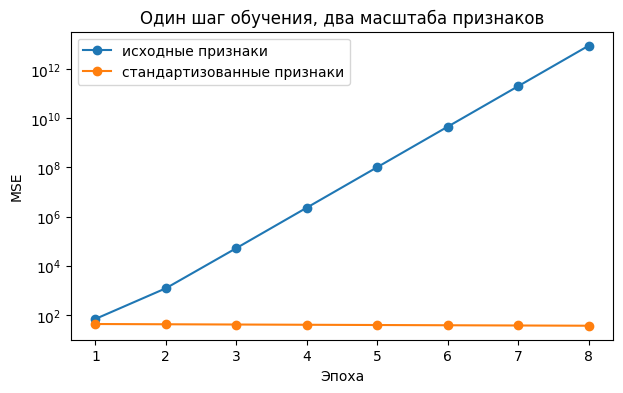

Финальная MSE стандартизованной модели: 17.2649


In [11]:
ETA_DEMO = 0.01

raw_demo = LinearRegressionSGD(
    learning_rate=ETA_DEMO,
    batch_size=N_TRAIN,
    max_epochs=8,
    random_state=42,
).fit(X_train, y_train)

scaled_demo = LinearRegressionSGD(
    learning_rate=ETA_DEMO,
    batch_size=N_TRAIN,
    max_epochs=200,
    random_state=42,
).fit(X_train_scaled, y_train)

comparison_first_epochs = pd.DataFrame({
    "эпоха": np.arange(1, 9),
    "MSE: исходные признаки": raw_demo.history_["train_mse"][:8],
    "MSE: стандартизованные признаки": scaled_demo.history_["train_mse"][:8],
})

display(comparison_first_epochs)

plt.figure(figsize=(7, 4))
plt.plot(
    comparison_first_epochs["эпоха"],
    comparison_first_epochs["MSE: исходные признаки"],
    marker="o",
    label="исходные признаки",
)
plt.plot(
    comparison_first_epochs["эпоха"],
    comparison_first_epochs["MSE: стандартизованные признаки"],
    marker="o",
    label="стандартизованные признаки",
)
plt.yscale("log")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Один шаг обучения, два масштаба признаков")
plt.legend()
plt.show()

print(f"Финальная MSE стандартизованной модели: {scaled_demo.history_['train_mse'][-1]:.4f}")

### Как измерить, насколько хорошо градиентный спуск решил задачу?

В начале notebook мы договорились использовать `lstsq` как практический эталон для этой небольшой least-squares задачи. Он решает ту же задачу МНК напрямую средствами численной линейной алгебры и не зависит от шага обучения.

Поэтому можно смотреть не только на абсолютную MSE, но и на **разрыв до эталона**:

$$
\mathrm{gap}_t
=
R(\theta_t)-R(\hat\theta_{\mathrm{lstsq}}).
$$

Это **не расстояние между параметрами**. Величина отвечает на другой вопрос: насколько MSE текущего состояния ещё выше лучшей MSE, найденной `lstsq` на тех же данных.

На графике ниже вертикальная ось логарифмическая: одинаковые расстояния по высоте соответствуют не одинаковым прибавкам, а изменениям примерно в одинаковое число раз. Так удобнее одновременно видеть большие и очень маленькие значения `gap`.


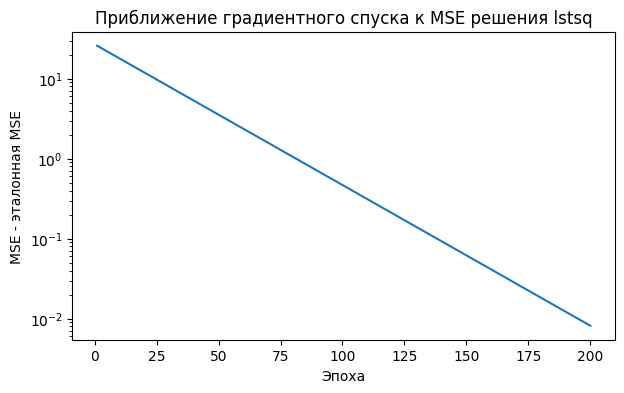

In [12]:
def optimization_gap(history_mse, reference_mse):
    """Разность между MSE по эпохам и эталонной MSE решения lstsq."""
    return np.asarray(history_mse, dtype=float) - reference_mse


scaled_reference_mse = mse_loss(
    fit_lstsq(X_train_scaled, y_train),
    add_intercept(X_train_scaled),
    y_train,
)


def plot_gap(model, reference_mse, title):
    """Показать разрыв по целевой функции в логарифмическом масштабе."""
    gap = optimization_gap(model.history_["train_mse"], reference_mse)
    epochs = np.arange(1, len(gap) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, np.maximum(gap, 1e-12))
    plt.yscale("log")
    plt.xlabel("Эпоха")
    plt.ylabel("MSE - эталонная MSE")
    plt.title(title)
    plt.show()


plot_gap(
    scaled_demo,
    scaled_reference_mse,
    "Приближение градиентного спуска к MSE решения lstsq",
)

На исходном масштабе $\eta=0.01$ оказался слишком большим. Это ещё не означает, что градиентный спуск **вообще** не может обучить ту же модель без стандартизации.

Проверим одну конкретную гипотезу: если заранее уменьшить шаг до $\eta=0.002$, станет ли обучение устойчивым? Это **не подбор гиперпараметра** и не поиск оптимального $\eta$: значение уже задано, а мы проверяем причинное объяснение увиденного эффекта.

После выполнения ячейки ответьте:

> **Что показали оба запуска с исходными признаками? Какую роль сыграла стандартизация: изменила саму линейную модель или сделала выбранный способ градиентной оптимизации удобнее?**


In [13]:
ETA_RAW_SMALL = 0.002

raw_small_step = LinearRegressionSGD(
    learning_rate=ETA_RAW_SMALL,
    batch_size=N_TRAIN,
    max_epochs=200,
    random_state=42,
).fit(X_train, y_train)

raw_reference_mse = mse_loss(
    fit_lstsq(X_train, y_train),
    add_intercept(X_train),
    y_train,
)

print(f"MSE после 200 эпох, исходный масштаб, eta=0.002: {raw_small_step.history_['train_mse'][-1]:.4f}")
print(f"Разрыв до lstsq: {raw_small_step.history_['train_mse'][-1] - raw_reference_mse:.4f}")
print(f"MSE после 200 эпох, стандартизованные признаки, eta=0.01: {scaled_demo.history_['train_mse'][-1]:.4f}")
print(f"Разрыв до lstsq: {scaled_demo.history_['train_mse'][-1] - scaled_reference_mse:.4f}")

MSE после 200 эпох, исходный масштаб, eta=0.002: 23.4312
Разрыв до lstsq: 6.1744
MSE после 200 эпох, стандартизованные признаки, eta=0.01: 17.2649
Разрыв до lstsq: 0.0082


**Ваш ответ:**

Эксперименты на исходных признаках продемонстрировали сильную зависимость устойчивости градиентного спуска от масштаба признаков при константном шаге обучения. В исходных данных дисперсия признака x2 на два порядка превышает дисперсию признака x1, из-за чего спектральный радиус матрицы Гессе и соответствующая константа Липшица градиента оказываются слишком велики для шага eta=0.01, что вызывает экспоненциальное накопление ошибок и численную расходимость. При снижении шага до eta=0.002 алгоритм стабилизируется, однако скорость продвижения вдоль слабо выраженных направлений оказывается крайне низкой, в результате чего за 200 эпох модель не успевает приблизиться к аналитическому оптимуму. Стандартизация не изменяет саму линейную модель и предельное качество аппроксимации, но трансформирует геометрию целевой функции, делая линии уровня сферическими и снижая число обусловленности гессиана, что обеспечивает быструю и устойчивую сходимость градиентного спуска с единым темпом обучения по всем направлениям.

### После раздела B

После этого раздела важно различать две вещи: какое минимальное значение ошибки вообще доступно линейной модели и насколько хорошо выбранный алгоритм успел подобрать параметры.

Для SGD и других простых градиентных методов стандартизация **не является обязательным математическим условием**: алгоритм может успешно работать и на исходных признаках, если шаг обучения и остальные настройки подходят к их масштабу. Но при сильно различающихся масштабах признаков стандартизация обычно делает обучение устойчивее и настройку шага проще, поэтому на практике её часто рекомендуют.

В разделе C оставим признаки стандартизованными, чтобы дальше не смешивать влияние масштаба с влиянием размера батча.

# C. Размер батча и остановка обучения — 2 балла

В разделе B мы устранили проблему масштаба и получили `X_train_scaled`. **Дальше продолжаем работать именно с этой стандартизованной выборкой и с `scaled_reference_mse`, уже вычисленной выше.**

Теперь меняем другой элемент процедуры обучения — размер батча.

## Задание 5. Полный батч, мини-батч и один объект — 1 балл

Продолжаем использовать **те же** `X_train_scaled`, `y_train` и `scaled_reference_mse`, которые получили в разделе B. Новую выборку и новый `StandardScaler` здесь создавать не нужно.

Сравним три режима одного и того же класса:

- `batch_size=640` — один полный градиент и одно обновление за эпоху;
- `batch_size=32` — 20 обновлений по мини-батчам за эпоху;
- `batch_size=1` — 640 стохастических обновлений за эпоху.

Во всех трёх запусках фиксируем:

- шаг обучения $\eta=0.005$;
- 300 эпох;
- нулевую инициализацию;
- `random_state=42`.

Сначала получите итоговую таблицу, затем два графика траектории обучения.

После всех опытов задания 5 дайте **единый комментарий**:

1. почему `batch_size=1` уже за первую эпоху может оказаться близко к хорошей MSE;
2. почему `batch_size=32` при сравнении по эпохам выглядит быстрее полного батча;
3. почему из этого нельзя сделать универсальный вывод «батч 32 лучше батча 640»;
4. что показывает повторение `batch_size=1` с разными `random_state`.


In [14]:
LEARNING_RATE_C = 0.005
MAX_EPOCHS_C = 300
BATCH_SIZES = [N_TRAIN, 32, 1]

models_by_batch = {}

for batch_size in BATCH_SIZES:
    models_by_batch[batch_size] = LinearRegressionSGD(
        learning_rate=LEARNING_RATE_C,
        batch_size=batch_size,
        max_epochs=MAX_EPOCHS_C,
        random_state=42,
    ).fit(X_train_scaled, y_train)

summary_by_batch = pd.DataFrame([
    {
        "batch_size": batch_size,
        "обновлений за эпоху": int(np.ceil(N_TRAIN / batch_size)),
        "всего обновлений": int(model.history_["n_updates"][-1]),
        "финальная MSE": float(model.history_["train_mse"][-1]),
        "финальный gap": float(model.history_["train_mse"][-1] - scaled_reference_mse),
    }
    for batch_size, model in models_by_batch.items()
])

display(summary_by_batch)

,batch_size,обновлений за эпоху,всего обновлений,финальная MSE,финальный gap
0,640,1,300,17.320525,0.063744
1,32,20,6000,17.256799,0.000018
2,1,640,192000,17.458414,0.201633


### Два взгляда на одну траекторию обучения

Первый график показывает обычную MSE на обучающей выборке. Он отвечает на вопрос: **какой уровень ошибки имеет модель сейчас?**

На втором графике показан разрыв до `lstsq`. Он отвечает на более узкий вопрос: **сколько по целевой функции ещё осталось до практически оптимального решения той же задачи МНК?**

У второго графика логарифмическая вертикальная шкала. Поэтому он особенно удобен, когда один запуск ещё далёк от эталона, а другой уже отличается от него на тысячные доли.


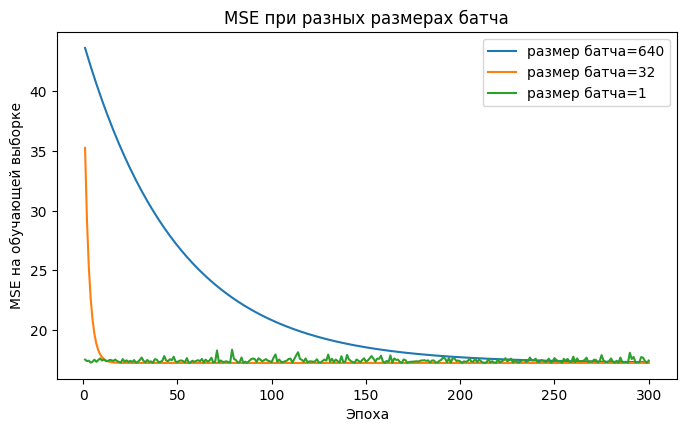

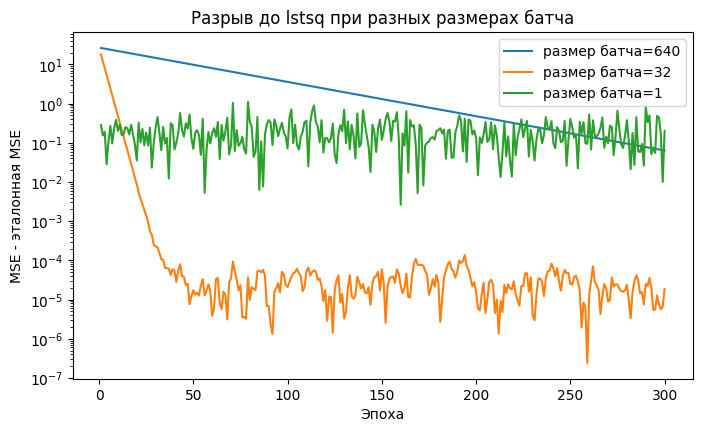

In [15]:
def plot_batch_trajectories(models_by_batch, reference_mse):
    """Показать MSE и разрыв до lstsq для разных размеров батча."""
    plt.figure(figsize=(8, 4.5))
    for batch_size, model in models_by_batch.items():
        epochs = np.arange(1, len(model.history_["train_mse"]) + 1)
        plt.plot(epochs, model.history_["train_mse"], label=f"размер батча={batch_size}")
    plt.xlabel("Эпоха")
    plt.ylabel("MSE на обучающей выборке")
    plt.title("MSE при разных размерах батча")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    for batch_size, model in models_by_batch.items():
        gap = np.maximum(model.history_["train_mse"] - reference_mse, 1e-12)
        epochs = np.arange(1, len(gap) + 1)
        plt.plot(epochs, gap, label=f"размер батча={batch_size}")
    plt.yscale("log")
    plt.xlabel("Эпоха")
    plt.ylabel("MSE - эталонная MSE")
    plt.title("Разрыв до lstsq при разных размерах батча")
    plt.legend()
    plt.show()


plot_batch_trajectories(models_by_batch, scaled_reference_mse)

Теперь отдельно посмотрим на `batch_size=1`. При каждом обновлении градиент строится всего по одному объекту, поэтому конкретный порядок объектов внутри эпохи сильнее влияет на траекторию.

Мы зафиксируем обучающую выборку, начальные параметры, шаг обучения и число эпох. Изменим только `random_state`, то есть последовательность случайных перестановок объектов.

Запустите пять обучений и сравните итоговые MSE и `gap`. Цель опыта — увидеть, остаётся ли результат абсолютно детерминированным после того, как данные уже зафиксированы, или стохастическая процедура обучения сама добавляет изменчивость.


In [16]:
seed_rows = []

for seed in [1, 2, 3, 4, 5]:
    model = LinearRegressionSGD(
        learning_rate=LEARNING_RATE_C,
        batch_size=1,
        max_epochs=MAX_EPOCHS_C,
        random_state=seed,
    ).fit(X_train_scaled, y_train)

    seed_rows.append({
        "random_state": seed,
        "финальная MSE": model.history_["train_mse"][-1],
        "финальный gap": model.history_["train_mse"][-1] - scaled_reference_mse,
    })

sgd_seed_results = pd.DataFrame(seed_rows)
display(sgd_seed_results)

,random_state,финальная MSE,финальный gap
0,1,17.392449,0.135668
1,2,17.435838,0.179057
2,3,17.385446,0.128665
3,4,17.437515,0.180734
4,5,17.544648,0.287867


**Ваш ответ:**

При размере батча 1 модель уже на первой эпохе оказывается близко к хорошему качеству, поскольку за один проход по данным она выполняет 640 последовательных коррекций параметров вдоль направлений градиентов отдельных наблюдений, непрерывно продвигаясь к оптимуму, тогда как при полном батче за ту же эпоху совершается лишь одно усредненное обновление.

Пакетный режим с размером батча 32 демонстрирует более быструю сходимость по шкале эпох по сравнению с полным батчем благодаря 20 обновлениям за эпоху при сохранении достаточной устойчивости градиента, дисперсия которого подавляется усреднением по подвыборке.

Из этого нельзя сделать общий вывод о превосходстве батча 32 над полным батчем: число эпох не отражает реальное астрономическое время вычислений, так как операции с большими матрицами в полнопакетном режиме эффективно утилизируют векторные инструкции процессора и параллелизм графических ускорителей, тогда как частые микрообновления создают накладные расходы на последовательную синхронизацию весов.

Повторение обучения со стохастическим размером батча 1 при различных случайных зернах показывает наличие остаточной вариативности оптимизационного зазора, вызванной блужданием параметров в стохастической окрестности оптимума из-за неубывающего шума одноточечных оценок градиента.

## Задание 6. Когда остановить обучение? — 1 балл

До сих пор `LinearRegressionSGD` всегда выполнял ровно `max_epochs` эпох. В сам класс мы **не будем** добавлять досрочную остановку: сейчас полезнее отдельно понять смысл возможных критериев, не смешивая анализ с новой реализацией.

После уже выполненного запуска у нас есть `history_`. По этой истории рассмотрим три сигнала.

**1. Изменение MSE между соседними эпохами**

$$
\Delta R_t=|R_t-R_{t-1}|.
$$

Малое значение говорит лишь о том, что MSE почти не изменилась за последнюю эпоху.

**2. Норма полного градиента**

$$
g_t=\lVert\nabla R(\theta_t)\rVert_2.
$$

Малый градиент означает, что локально направление наиболее быстрого уменьшения функции уже слабое.

**3. Изменение параметров за эпоху**

$$
\Delta\theta_t
=
\lVert\theta_t-\theta_{t-1}\rVert_2.
$$

Малое значение означает, что сами параметры почти не сдвинулись.

Код ниже **не останавливает обучение**. Он постфактум просматривает сохранённую историю и находит, на какой эпохе условный критерий впервые пересёк заданный порог. Так мы можем понять, что именно такой критерий сообщил бы нам, если бы мы встроили его в `fit`.

Сравним обычный шаг и намеренно крошечный шаг, а затем посмотрим на шумную стохастическую траекторию.

После эксперимента ответьте:

> **Почему маленькое изменение MSE или параметров ещё не гарантирует, что мы близки к минимуму? Что дополнительно показывают `gap` и норма градиента? Почему для стохастической траектории одно случайное пересечение порога особенно ненадёжно?**


In [17]:
def stopping_diagnostics(model, reference_mse):
    """Собрать диагностические величины по уже сохранённой истории обучения.

    Функция ничего не переобучает и ничего не останавливает. Она только
    преобразует ``model.history_`` в таблицу, удобную для анализа.
    """
    mse = np.asarray(model.history_["train_mse"], dtype=float)

    # Для первой эпохи предыдущего значения MSE ещё нет, поэтому ставим NaN.
    loss_change = np.full_like(mse, np.nan)
    loss_change[1:] = np.abs(np.diff(mse))

    return pd.DataFrame({
        "epoch": np.arange(1, len(mse) + 1),
        "train_mse": mse,
        "gap": mse - reference_mse,
        "loss_change": loss_change,
        "grad_norm": np.asarray(model.history_["full_grad_norm"], dtype=float),
        "step_norm": np.asarray(model.history_["epoch_step_norm"], dtype=float),
    })


def first_below(values, threshold):
    """Найти первую эпоху, на которой величина стала меньше порога."""
    values = np.asarray(values, dtype=float)
    mask = np.isfinite(values) & (values < threshold)
    if not mask.any():
        return None
    return int(np.flatnonzero(mask)[0] + 1)


# Пороговые значения заданы заранее: здесь мы не подбираем их.
LOSS_CHANGE_TOL = 1e-2
STEP_TOL = 1e-3


Сначала возьмём два запуска **полного** градиентного спуска на одних и тех же стандартизованных данных:

- `ETA_NORMAL = 0.02` — рабочий шаг;
- `ETA_TINY = 1e-5` — намеренно очень маленький шаг.

В обоих случаях модель всё равно отработает 300 эпох. Затем код найдёт первую эпоху, когда

$$
\Delta R_t<10^{-2}
$$

и первую эпоху, когда

$$
\Delta\theta_t<10^{-3}.
$$

Для найденной эпохи мы дополнительно выведем MSE, `gap` и норму полного градиента. Именно сопоставление этих величин и является содержанием опыта.


In [18]:
ETA_NORMAL = 0.02
ETA_TINY = 1e-5

normal_stop_model = LinearRegressionSGD(
    learning_rate=ETA_NORMAL,
    batch_size=N_TRAIN,
    max_epochs=300,
    random_state=42,
).fit(X_train_scaled, y_train)

tiny_stop_model = LinearRegressionSGD(
    learning_rate=ETA_TINY,
    batch_size=N_TRAIN,
    max_epochs=300,
    random_state=42,
).fit(X_train_scaled, y_train)

rows = []

for name, model in [
    ("нормальный шаг", normal_stop_model),
    ("очень маленький шаг", tiny_stop_model),
]:
    diag = stopping_diagnostics(model, scaled_reference_mse)

    loss_epoch = first_below(diag["loss_change"], LOSS_CHANGE_TOL)
    step_epoch = first_below(diag["step_norm"], STEP_TOL)

    for criterion, epoch in [
        ("малое изменение MSE", loss_epoch),
        ("малое изменение параметров", step_epoch),
    ]:
        if epoch is None:
            continue
        row = diag.iloc[epoch - 1]
        criterion_value = (
            row["loss_change"]
            if criterion == "малое изменение MSE"
            else row["step_norm"]
        )
        rows.append({
            "запуск": name,
            "критерий": criterion,
            "эпоха": epoch,
            "значение критерия": criterion_value,
            "MSE": row["train_mse"],
            "gap": row["gap"],
            "норма градиента": row["grad_norm"],
        })

stopping_table = pd.DataFrame(rows)
display(stopping_table)

,запуск,критерий,эпоха,значение критерия,MSE,gap,норма градиента
0,нормальный шаг,малое изменение MSE,67,0.009526,17.368498,0.111717,0.669219
1,нормальный шаг,малое изменение параметров,132,0.000976,17.257329,0.000548,0.046855
2,очень маленький шаг,малое изменение MSE,2,0.001079,44.150735,26.893954,10.385726
3,очень маленький шаг,малое изменение параметров,1,0.000104,44.151814,26.895033,10.385934


Наконец, вернёмся к стохастическому запуску `batch_size=1` из задания 5. На шумной траектории величина $\Delta R_t$ может случайно оказаться маленькой в отдельную эпоху, а затем снова вырасти.

In [19]:
sgd_diag = stopping_diagnostics(models_by_batch[1], scaled_reference_mse)
small_change_epochs = sgd_diag.loc[
    sgd_diag["loss_change"] < LOSS_CHANGE_TOL,
    "epoch",
].tolist()

print("Первые эпохи с очень маленьким изменением MSE:", small_change_epochs[:15])
print("Всего таких эпох:", len(small_change_epochs))

Первые эпохи с очень маленьким изменением MSE: [13, 121, 175, 177, 180, 188, 234, 246, 259, 264, 287]
Всего таких эпох: 11


**Ваш ответ:**

Сравнение запусков демонстрирует, что при исчезающе малом темпе обучения оба критерия ранней остановки (малое изменение значения ошибки и малая длина шага параметров) срабатывают преждевременно на начальных эпохах, когда модель находится далеко от минимума. Это объясняется тем, что величина изменения функции потерь и длина шага прямо пропорциональны выбранному темпу обучения eta: при малом шаге алгоритм практически останавливается, создавая ложную видимость стабилизации, тогда как норма истинного градиента и оптимизационный зазор gap остаются высокими.

Норма градиента служит объективным критерием первого порядка, указывающим на истинную близость к стационарной точке независимо от масштаба шага.

На шумной стохастической траектории с размером батча 1 одиночное пересечение порога не является надежным свидетельством остановки, поскольку может быть вызвано случайным взаимным гашением стохастических приращений за конкретную эпоху; далее флуктуации возобновляются, что требует применения скользящих окон или критериев ранней остановки на валидационной выборке.

### После раздела C

После этого раздела вы должны уметь читать график обучения с учётом того, **что считается одной эпохой и сколько обновлений скрывается внутри неё**, а также различать «алгоритм почти не двигается» и «алгоритм действительно находится рядом с минимумом».


# D. Случайность оценки качества — 2 балла

До сих пор обучающая выборка почти всегда была фиксирована, а мы разбирались с оптимизацией. Теперь временно уберём её из центра внимания: модели будем обучать через `lstsq` и исследуем **оценку качества на новых данных**.

## Совокупность, выборка и интересующее нас качество

Наш `sample_regression` задаёт вероятностный механизм появления объектов. Обозначим соответствующее распределение через $P$.

Важно различать:

- **распределение / генеральную совокупность $P$** — вероятностную модель того, какие объекты вообще могут появляться;
- **обучающую выборку** — конечный случайный набор объектов из $P$, на котором подбираются параметры модели;
- **оценочную выборку** — другой конечный случайный набор объектов из $P$, на котором уже обученную модель проверяют.

Каждый вызов

```python
sample_regression(n, random_state)
```

даёт одну случайную выборку размера $n$ из того же $P$.

Для фиксированной модели $f$ нас в идеале интересует её типичная ошибка на новых объектах. Формально RMSE на распределении можно записать как

$$
\mathrm{RMSE}_P(f)
=
\sqrt{
\mathbb E_{(X,Y)\sim P}
\left[(Y-f(X))^2\right]
}.
$$

Знак математического ожидания $\mathbb E$ здесь означает мысленное усреднение ошибки по **всем возможным новым объектам, которые порождает $P$**. На практике всю совокупность мы не наблюдаем, поэтому эту величину напрямую обычно не знаем.

На конечной оценочной выборке $S$ размера $m$ доступна только

$$
\widehat{\mathrm{RMSE}}_S(f)
=
\sqrt{
\frac{1}{m}
\sum_{i=1}^{m}
(y_i-f(x_i))^2
}.
$$

Поскольку сама выборка $S$ случайна, наблюдаемое значение RMSE тоже является случайной величиной.

В синтетической задаче у нас есть особая возможность: генератор позволяет многократно получать независимые выборки из одного и того же $P$ и буквально увидеть распределение возможных значений метрики. Повторяющиеся случайные симуляции такого типа принято называть **экспериментом Монте-Карло**. Здесь это не новый алгоритм обучения, а способ исследовать выборочную изменчивость оценки.


Сначала один раз обучим полную линейную модель на нашей фиксированной обучающей выборке. После этого её параметры **замораживаются**: в первом эксперименте раздела D нового `fit` больше не будет.

Также сгенерируем отдельную большую контрольную выборку из 100 000 объектов. Это **не генеральная совокупность**, а просто очень большая независимая выборка. Её RMSE будет достаточно стабильным численным ориентиром для учебного эксперимента.

Перед большим экспериментом посмотрим на три маленькие оценочные выборки по 20 объектов. Уже здесь можно увидеть, что одна и та же модель получает разные значения RMSE без какого-либо переобучения.


In [20]:
full_theta = fit_lstsq(X_train, y_train)

REFERENCE_SIZE = 100_000
X_reference, y_reference = sample_regression(REFERENCE_SIZE, random_state=100_001)
reference_full_rmse = rmse(y_reference, predict_theta(full_theta, X_reference))

print(f"RMSE фиксированной модели на большой контрольной выборке: {reference_full_rmse:.4f}")

# Для интуиции: три маленькие независимые выборки одной и той же модели.
for seed in [501, 502, 503]:
    X_tmp, y_tmp = sample_regression(20, seed)
    score = rmse(y_tmp, predict_theta(full_theta, X_tmp))
    print(f"RMSE на выборке из 20 объектов, random_state={seed}: {score:.4f}")

RMSE фиксированной модели на большой контрольной выборке: 4.0045
RMSE на выборке из 20 объектов, random_state=501: 3.5057
RMSE на выборке из 20 объектов, random_state=502: 4.2582
RMSE на выборке из 20 объектов, random_state=503: 3.1903


## Задание 7. Одна модель, много оценочных выборок — 1 балл

Теперь проведём систематический **Монте-Карло эксперимент**.

Для каждого размера

$$
m\in\{20,50,200,1000\}
$$

нужно 300 раз:

1. сгенерировать новую независимую оценочную выборку размера $m$;
2. получить на ней предсказания **той же фиксированной** модели `full_theta`;
3. посчитать RMSE;
4. сохранить результат.

Внутри цикла не должно быть нового `fit`: если переобучать модель, мы смешаем изменчивость обучения с изменчивостью оценки.

После выполнения готовой итоговой ячейки ответьте:

> **Что в 300 повторах фиксировано, а что случайно меняется? Как меняются центр и разброс распределения RMSE при росте размера оценочной выборки? Как это связано с тем, что RMSE на конечной выборке лишь оценивает качество модели на распределении?**


In [21]:
def repeated_evaluation(theta, eval_size, n_repeats, random_state):
    scores = []
    rng = np.random.default_rng(random_state)

    for _ in range(n_repeats):
        sample_seed = int(rng.integers(0, 2**32 - 1))
        X_eval, y_eval = sample_regression(eval_size, sample_seed)
        y_pred = predict_theta(theta, X_eval)
        scores.append(rmse(y_eval, y_pred))

    return np.asarray(scores)

,размер оценочной выборки,средний RMSE,std RMSE
0,20,3.940084,0.656136
1,50,3.978377,0.408681
2,200,4.003972,0.183289
3,1000,3.995659,0.086828


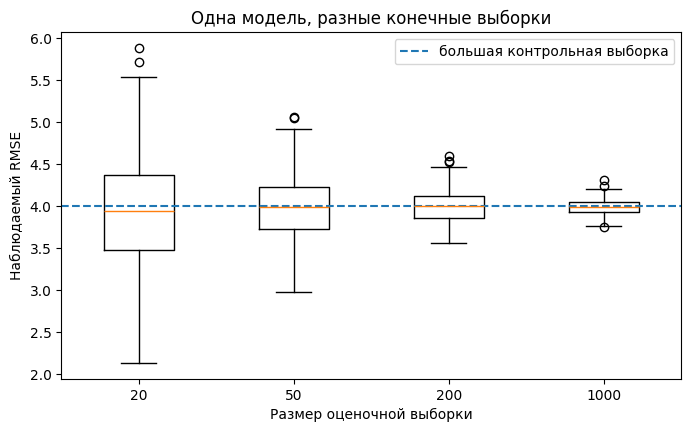

In [22]:
EVAL_SIZES = [20, 50, 200, 1000]
N_REPEATS = 300

# После реализации repeated_evaluation эта ячейка должна выполниться без изменений.
eval_scores = {
    size: repeated_evaluation(
        full_theta,
        eval_size=size,
        n_repeats=N_REPEATS,
        random_state=10_000 + size,
    )
    for size in EVAL_SIZES
}

eval_summary = pd.DataFrame([
    {
        "размер оценочной выборки": size,
        "средний RMSE": scores.mean(),
        "std RMSE": scores.std(ddof=1),
    }
    for size, scores in eval_scores.items()
])

display(eval_summary)

plt.figure(figsize=(8, 4.5))
plt.boxplot(
    [eval_scores[size] for size in EVAL_SIZES],
    tick_labels=[str(size) for size in EVAL_SIZES],
)
plt.axhline(reference_full_rmse, linestyle="--", label="большая контрольная выборка")
plt.xlabel("Размер оценочной выборки")
plt.ylabel("Наблюдаемый RMSE")
plt.title("Одна модель, разные конечные выборки")
plt.legend()
plt.show()

**Ваш ответ:**

В серии из 300 повторов фиксированными остаются параметры модели theta, структура процесса генерации данных DGP и размер контрольной выборки eval_size, в то время как конкретные значения признаков и стохастический шум каждого наблюдения генерируются независимо в каждой итерации.

По мере увеличения объема оценочной выборки центр распределения эмпирической RMSE стабилизируется около теоретического значения ошибки на генеральной совокупности, а дисперсия и межквартильный размах распределения монотонно убывают со скоростью, пропорциональной корню из объема выборки, в полном соответствии с центральной предельной теоремой.

Наблюдаемое значение RMSE на конечной выборке является точечной выборочной оценкой истинного функционала риска, поэтому на малых выборках оценка подвержена значительной случайной погрешности и может существенно отклоняться от реального качества модели исключительно из-за локальной специфики сгенерированных точек.

## Задание 8. Могут ли две близкие модели поменяться местами? — 1 балл

Теперь **сначала обучим две модели на одной и той же `X_train`**:

- `full` использует $x_1$ и $x_2$;
- `reduced` использует только $x_1$.

В нашем процессе генерации $x_2$ действительно несёт сигнал, но его вклад невелик относительно шума. Поэтому ожидается, что полная модель в среднем немного лучше, а различие между моделями — небольшое. Именно такой случай интересен: сможет ли конечная оценочная выборка иногда изменить наблюдаемый порядок моделей?

Сначала обучите обе модели через `lstsq` и оцените их на большой контрольной выборке. Затем проведите парный Монте-Карло эксперимент: в каждом повторе обе модели должны оцениваться **на одной и той же новой выборке**.

После таблицы и графика ответьте:

> **Что показывает большая контрольная выборка? Как часто на малых выборках порядок моделей меняется и что происходит с этой долей при росте размера выборки? Что можно и чего нельзя сказать по одному наблюдению «модель A получила меньшую RMSE, чем модель B»?**


In [23]:
# Сначала обучаем обе сравниваемые модели на одной обучающей выборке.
full_theta = fit_lstsq(X_train, y_train)

X_train_reduced = X_train[["x1"]]
reduced_theta = fit_lstsq(X_train_reduced, y_train)

full_ref_rmse = rmse(y_reference, predict_theta(full_theta, X_reference))
reduced_ref_rmse = rmse(
    y_reference,
    predict_theta(reduced_theta, X_reference[["x1"]]),
)

print(f"Полная модель, RMSE на большой выборке:       {full_ref_rmse:.4f}")
print(f"Сокращённая модель, RMSE на большой выборке:  {reduced_ref_rmse:.4f}")
print(f"Разница reduced - full:                 {reduced_ref_rmse - full_ref_rmse:.4f}")

Полная модель, RMSE на большой выборке:       4.0045
Сокращённая модель, RMSE на большой выборке:  4.0755
Разница reduced - full:                 0.0710


Для одной новой оценочной выборки введём величину

$$
\Delta
=
\mathrm{RMSE}_{\mathrm{reduced}}
-
\mathrm{RMSE}_{\mathrm{full}}.
$$

Если $\Delta>0$, на этой выборке полная модель лучше. Если $\Delta<0$, наблюдаемый порядок поменялся: сокращённая модель случайно получила меньшую RMSE.

Ключевой момент: **обе модели нужно оценивать на одной и той же выборке объектов**. Тогда разница относится именно к сравнению моделей, а не к тому, что каждая из них получила собственную случайную тестовую выборку.

Реализуйте функцию ниже. Она должна возвращать таблицу с RMSE обеих моделей и $\Delta$ для каждого повтора.

In [24]:
def paired_ranking_experiment(eval_size, n_repeats, random_state):
    rows = []
    rng = np.random.default_rng(random_state)

    for repeat in range(n_repeats):
        sample_seed = int(rng.integers(0, 2**32 - 1))
        X_eval, y_eval = sample_regression(eval_size, sample_seed)
        full_score = rmse(y_eval, predict_theta(full_theta, X_eval))
        reduced_score = rmse(y_eval, predict_theta(reduced_theta, X_eval[["x1"]]))

        rows.append({
            "repeat": repeat,
            "full_rmse": full_score,
            "reduced_rmse": reduced_score,
            "delta": reduced_score - full_score,
        })

    return pd.DataFrame(rows)

,размер оценочной выборки,средняя delta,доля смены порядка
0,20,0.081013,0.330000
1,50,0.076162,0.240000
2,200,0.076356,0.066667
3,1000,0.076585,0.003333


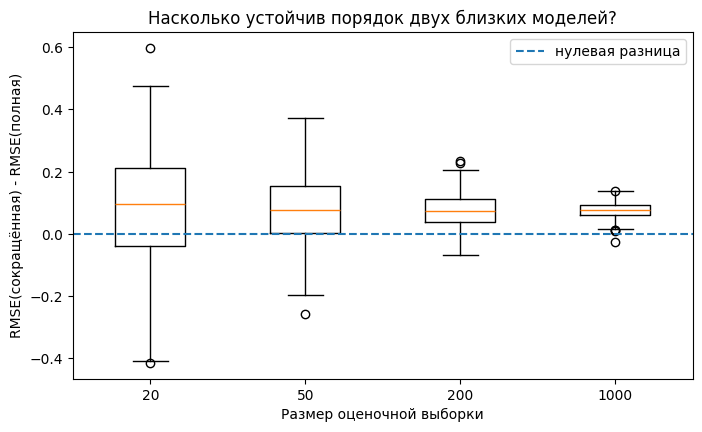

Пример одной выборки из 20 объектов, где порядок поменялся:
RMSE полной модели:       4.8350
RMSE сокращённой модели:  4.8008
delta:        -0.0342


In [25]:
# После реализации функции эта ячейка строит итоговую таблицу и график.
ranking_results = {
    size: paired_ranking_experiment(
        eval_size=size,
        n_repeats=N_REPEATS,
        random_state=20_000 + size,
    )
    for size in EVAL_SIZES
}

ranking_summary = pd.DataFrame([
    {
        "размер оценочной выборки": size,
        "средняя delta": df["delta"].mean(),
        "доля смены порядка": np.mean(df["delta"] < 0),
    }
    for size, df in ranking_results.items()
])

display(ranking_summary)

plt.figure(figsize=(8, 4.5))
plt.boxplot(
    [ranking_results[size]["delta"] for size in EVAL_SIZES],
    tick_labels=[str(size) for size in EVAL_SIZES],
)
plt.axhline(0.0, linestyle="--", label="нулевая разница")
plt.xlabel("Размер оценочной выборки")
plt.ylabel("RMSE(сокращённая) - RMSE(полная)")
plt.title("Насколько устойчив порядок двух близких моделей?")
plt.legend()
plt.show()

# Покажем один конкретный пример смены порядка на маленькой выборке.
reversals_20 = ranking_results[20].query("delta < 0")
if len(reversals_20) > 0:
    example = reversals_20.iloc[0]
    print("Пример одной выборки из 20 объектов, где порядок поменялся:")
    print(f"RMSE полной модели:       {example['full_rmse']:.4f}")
    print(f"RMSE сокращённой модели:  {example['reduced_rmse']:.4f}")
    print(f"delta:        {example['delta']:.4f}")

**Ваш ответ:**

Большая контрольная выборка фиксирует истинное математическое ожидание разности ошибок: средняя разность delta положительна, что подтверждает реальную информативность признака x2 для снижения ошибки предсказания на генеральной совокупности.

На малых выборках объема 20 выборочная дисперсия шума превышает полезный сигнал от признака x2, из-за чего доля инверсий порядка моделей оказывается высокой и сокращенная модель регулярно превосходит полную. При увеличении объема выборки дисперсия выборочной разности delta концентрируется около положительного среднего, а частота смены рангов стремится к нулю.

Единичное измерение на тестовой выборке ограниченного объема показывает лишь локальное соотношение ошибок на фиксированном наборе точек и не позволяет делать достоверный вывод о превосходстве одной модели над другой без статистической оценки значимости полученной разности.

## Ещё один источник изменчивости: обучающая выборка

В заданиях 7–8 мы фиксировали уже обученные модели и меняли оценочную выборку. Теперь **отдельно покажем** другой эффект: сама обучающая выборка тоже конечна и случайна.

Сделаем обратный контролируемый опыт:

- способ обучения всегда один и тот же — `lstsq`;
- большая контрольная выборка всегда одна и та же;
- меняется только обучающая выборка.

Код уже готов: это демонстрация, а не новое программное задание. После графика коротко объясните, почему разброс RMSE уменьшается при росте размера обучающей выборки.


,размер обучающей выборки,средний RMSE,std RMSE
0,30,4.244407,0.208773
1,100,4.070054,0.047200
2,500,4.017387,0.009164


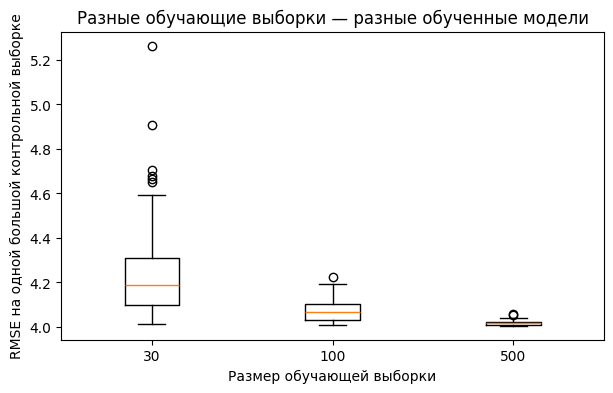

In [26]:
TRAIN_SIZES = [30, 100, 500]
TRAIN_REPEATS = 100


def training_sample_variability(train_size, n_repeats, random_state):
    """Переобучать lstsq на разных обучающих выборках и оценивать на одной большой."""
    rng = np.random.default_rng(random_state)
    scores = []

    for _ in range(n_repeats):
        sample_seed = int(rng.integers(0, 2**32 - 1))
        X_fresh_train, y_fresh_train = sample_regression(train_size, sample_seed)
        theta = fit_lstsq(X_fresh_train, y_fresh_train)
        score = rmse(y_reference, predict_theta(theta, X_reference))
        scores.append(score)

    return np.asarray(scores)


train_variability_scores = {
    size: training_sample_variability(
        train_size=size,
        n_repeats=TRAIN_REPEATS,
        random_state=30_000 + size,
    )
    for size in TRAIN_SIZES
}

train_variability_summary = pd.DataFrame([
    {
        "размер обучающей выборки": size,
        "средний RMSE": scores.mean(),
        "std RMSE": scores.std(ddof=1),
    }
    for size, scores in train_variability_scores.items()
])

display(train_variability_summary)

plt.figure(figsize=(7, 4))
plt.boxplot(
    [train_variability_scores[size] for size in TRAIN_SIZES],
    tick_labels=[str(size) for size in TRAIN_SIZES],
)
plt.xlabel("Размер обучающей выборки")
plt.ylabel("RMSE на одной большой контрольной выборке")
plt.title("Разные обучающие выборки — разные обученные модели")
plt.show()

**Короткая интерпретация (не отдельный балл):**

Различные обучающие выборки формируют различные матрицы ковариаций признаков и откликов, что приводит к вариативности коэффициентов метода наименьших квадратов вокруг их теоретических значений. На малых объемах обучающей выборки выборочные оценки параметров обладают высокой дисперсией, что транслируется в разброс ошибки прогноза на независимом тесте. С ростом размера train выборочные моменты сходятся по вероятности к истинным параметрам генеральной совокупности, дисперсия оценок весов затухает, а результирующее качество модели монотонно приближается к теоретическому пределу точности.

### После раздела D

После этого раздела важно различать **качество фиксированной модели на распределении** и **метрику, наблюдаемую на одной конечной выборке**, а также помнить, что результат может меняться и из-за обучающих данных, и из-за данных для оценки.

# E. Итоговая диагностика — 1 балл

## Задание 9. Как разобраться, почему изменился RMSE?

Коллега говорит:

> «Я перезапустил эксперимент, RMSE изменился. Значит, модель нестабильна».

Одного такого наблюдения недостаточно, потому что между запусками могли измениться разные части эксперимента.

Предложите **три коротких контролируемых опыта**, которые отдельно проверят влияние:

1. случайности стохастической оптимизации;
2. обучающей выборки;
3. оценочной выборки.

Для каждого опыта опишите:

- что вы зафиксируете;
- что будете менять между повторами;
- какую величину будете сравнивать;
- по какому результату поймёте, что этот источник действительно заметно влияет на итоговый RMSE.

**Ваш ответ:**

Для изолированной проверки случайности стохастической оптимизации необходимо зафиксировать обучающую выборку, тестовую выборку, архитектуру модели и начальное приближение весов. Варьировать следует исключительно значение параметра random_state оптимизатора, определяющее последовательность перестановок объектов и состав батчей. Сравнению подлежит эмпирическое распределение RMSE на фиксированном тесте по серии повторных запусков. Значимое влияние фактора подтверждается в том случае, если стандартное отклонение RMSE сопоставимо с разницей в качестве между альтернативными моделями или существенно превосходит аналитический зазор оптимизации.

Для проверки влияния случайности обучающей выборки следует использовать детерминированный алгоритм оценивания параметров (аналитический метод наименьших квадратов) и зафиксировать единую большую контрольную тестовую выборку. Изменяются случайные зерна генерации обучающих выборок равного объема из одного и того же распределения. Сравнивается дисперсия RMSE обученных моделей на фиксированной контрольной выборке. Влияние признается доминирующим, если разброс ошибки между моделями, обученными на разных выборках, превышает погрешность оптимизационных алгоритмов и монотонно затухает с увеличением объема обучающего набора.

Для проверки влияния случайности оценочной выборки требуется зафиксировать единый вектор обученных параметров модели. Варьированию подлежат независимые тестовые выборки фиксированного размера, извлекаемые из распределения данных. Оценивается размах и стандартное отклонение получаемых значений RMSE. Значимость фактора доказывается широким доверительным интервалом метрики на малых объемах валидационных данных и его систематическим сужением при наращивании объема теста в соответствии со свойствами выборочных средних.

# Что мы сделали в этой работе

За одну домашнюю работу мы несколько раз использовали одну и ту же линейную модель, но меняли разные части процедуры.

- Реализовали обучение по батчам и ввели понятие эпохи.
- Сравнили исходный и стандартизованный масштаб признаков и увидели, как он связан с численным поведением градиентного спуска.
- Разделили размер батча, число эпох и число обновлений параметров.
- Исследовали несколько возможных сигналов остановки обучения.
- Провели Монте-Карло эксперименты с конечными оценочными выборками.
- Увидели, что изменчивость результата может приходить из обучающих данных, стохастической оптимизации и оценочных данных.

Эта логика понадобится дальше, когда появятся более сложные модели, подбор гиперпараметров и более системные процедуры валидации.


---

## Перед сдачей

- Выполните ноутбук сверху вниз после перезапуска ядра.
- Убедитесь, что все автопроверки проходят.
- Не меняйте заданные `random_state`, если этого прямо не требует задание.
- В заданиях 7–8 не переобучайте фиксированные модели внутри цикла по тестовым выборкам.
- Все блоки **«Ваш ответ»** должны содержать содержательную интерпретацию именно полученных результатов.
- У графиков должны быть понятные подписи осей и заголовки.